In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [2]:
df = pd.read_csv("Aluminium_Dataset.csv")  # Load your dataset
df.head()

,Date,Price,Open,High,Low,Vol.,Change %
0,31-12-2024 00:00,19775,19800,19815,19740,9140,0.05
1,30-12-2024 00:00,19765,19785,19885,19700,14730,0.00
2,27-12-2024 00:00,19765,19810,19830,19710,19160,-0.20
3,26-12-2024 00:00,19805,19880,19915,19705,24870,-0.38
4,25-12-2024 00:00,19880,19950,19985,19810,31780,0.28


In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 969 entries, 0 to 968
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Date      969 non-null    object 
 1   Price     969 non-null    int64  
 2   Open      969 non-null    int64  
 3   High      969 non-null    int64  
 4   Low       969 non-null    int64  
 5   Vol.      969 non-null    int64  
 6   Change %  969 non-null    float64
dtypes: float64(1), int64(5), object(1)
memory usage: 53.1+ KB


,Price,Open,High,Low,Vol.,Change %
count,969.000000,969.000000,969.000000,969.000000,969.000000,969.000000
mean,19378.059856,19380.252838,19544.422085,19218.766770,58064.747162,0.029082
std,1519.403650,1529.440447,1559.267193,1487.479235,75002.282118,1.015786
min,14725.000000,14675.000000,14850.000000,14650.000000,1300.000000,-5.930000
25%,18520.000000,18525.000000,18670.000000,18405.000000,10430.000000,-0.490000
50%,19055.000000,19065.000000,19220.000000,18920.000000,22100.000000,0.050000
75%,20295.000000,20295.000000,20435.000000,20135.000000,75020.000000,0.590000
max,24330.000000,24680.000000,25245.000000,24105.000000,550060.000000,3.660000


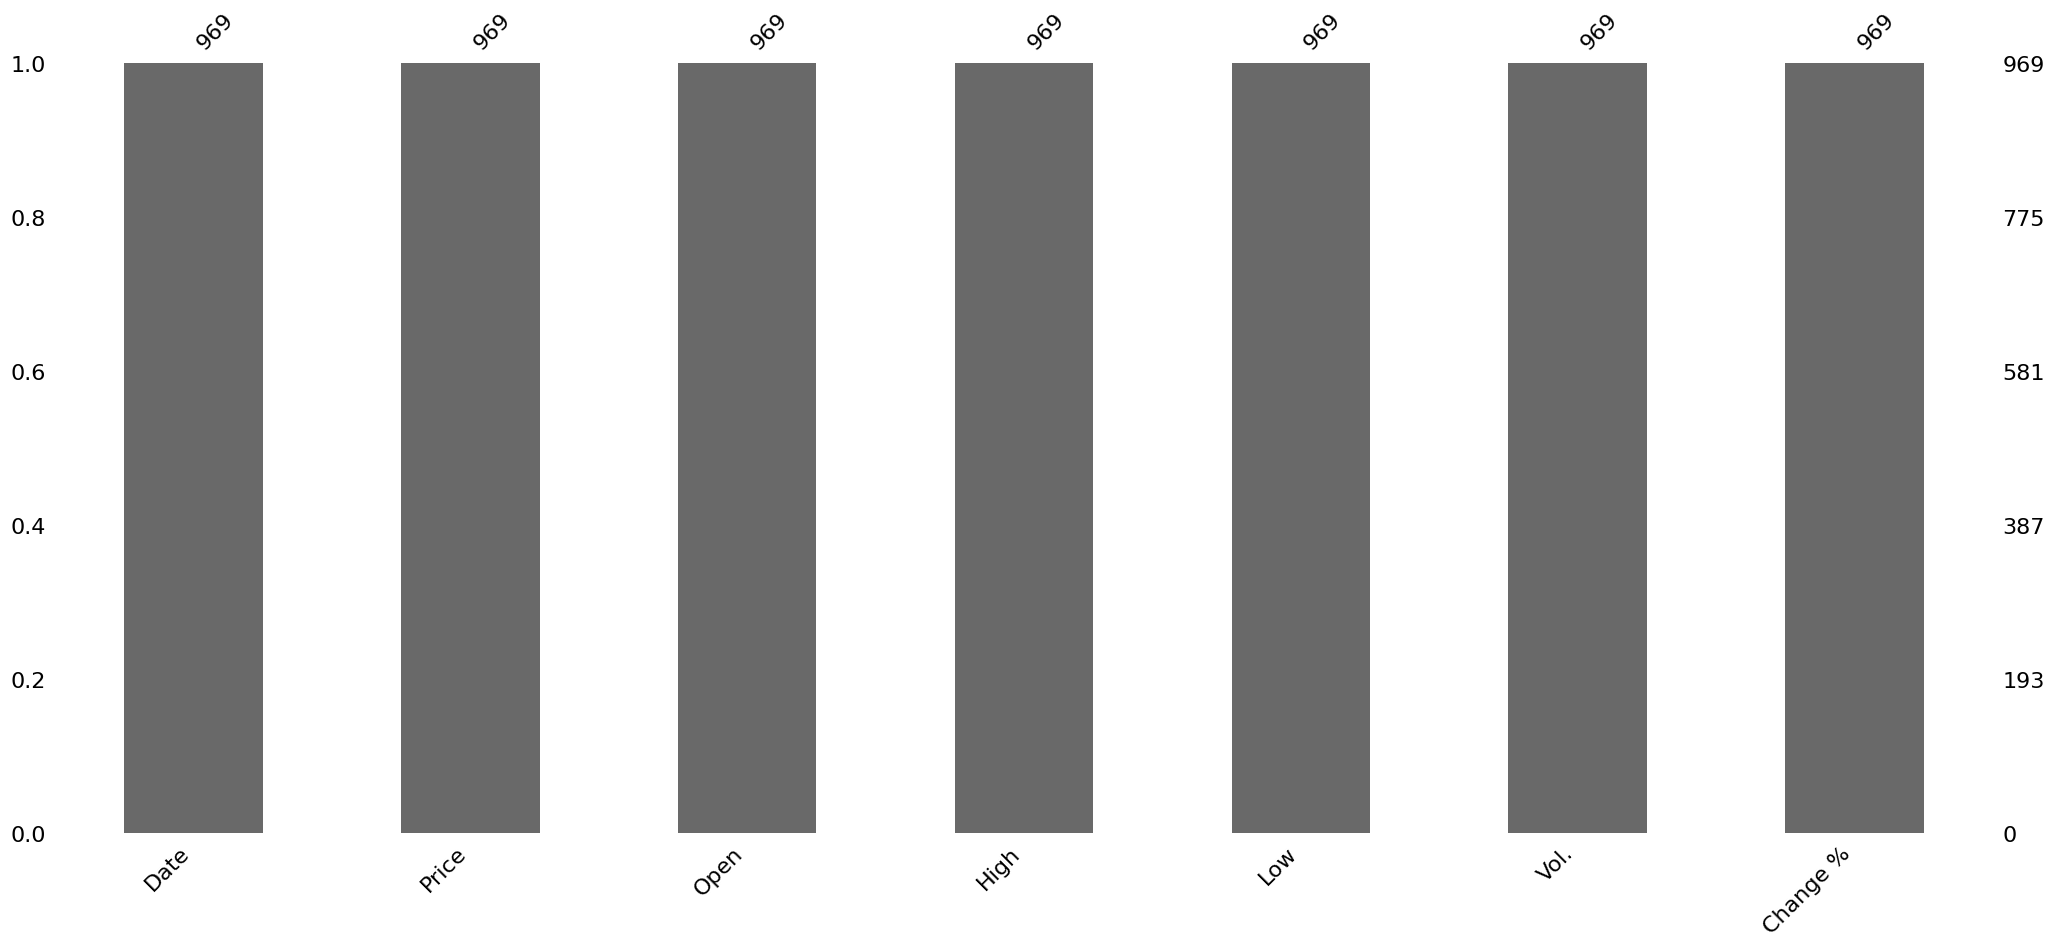

Date        0
Price       0
Open        0
High        0
Low         0
Vol.        0
Change %    0
dtype: int64


In [4]:
msno.bar(df)
plt.show()

print(df.isnull().sum())

#Data Visualization

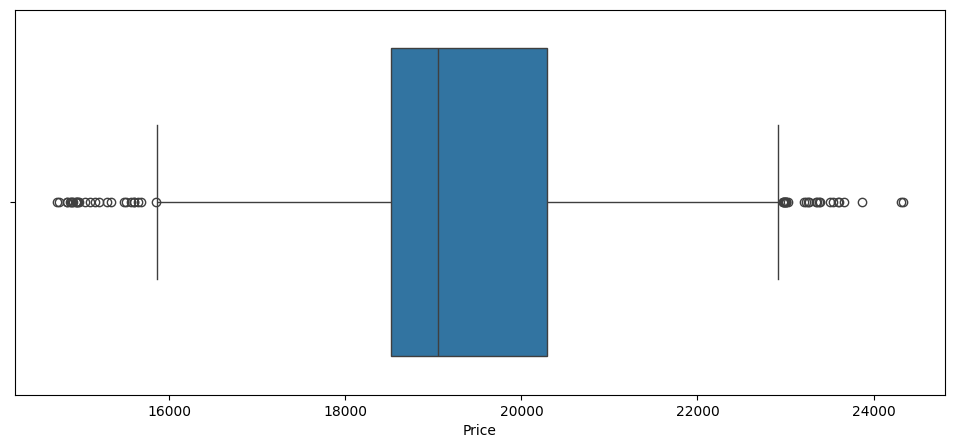

In [6]:
plt.figure(figsize=(12,5))
sns.boxplot(data=df, x="Price")
plt.show()

# Remove outliers using IQR
Q1 = df["Price"].quantile(0.25)
Q3 = df["Price"].quantile(0.75)
IQR = Q3 - Q1
df = df[(df["Price"] >= (Q1 - 1.5 * IQR)) & (df["Price"] <= (Q3 + 1.5 * IQR))]

# Time series Analysis

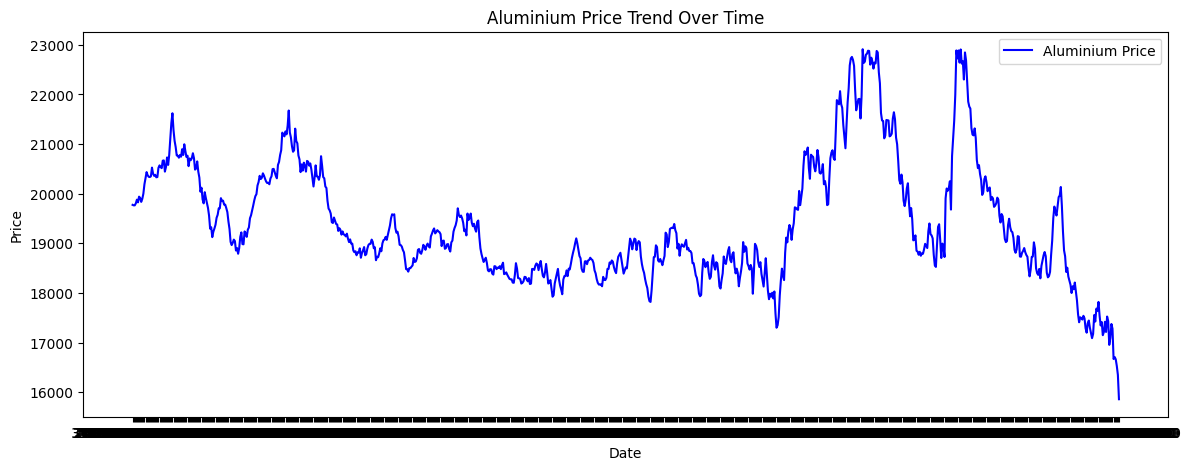

In [8]:
plt.figure(figsize=(14,5))
plt.plot(df["Date"], df["Price"], label="Aluminium Price", color="blue")
plt.xlabel("Date")
plt.ylabel("Price")
plt.title("Aluminium Price Trend Over Time")
plt.legend()
plt.show()

<ipython-input-10-d5931fc8874d>:1: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["Date"] = pd.to_datetime(df["Date"])


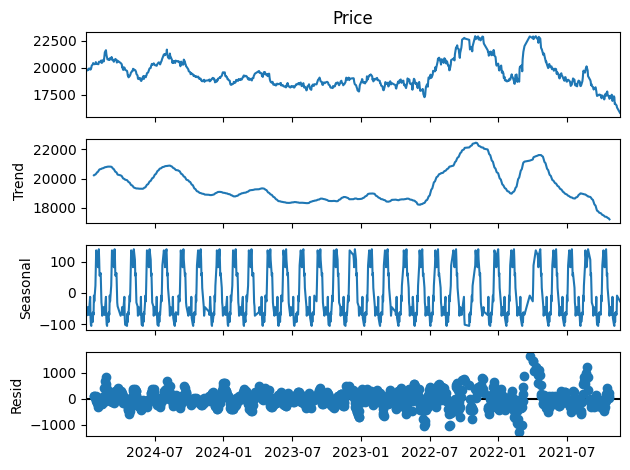

In [10]:
df["Date"] = pd.to_datetime(df["Date"])
df.set_index("Date", inplace=True)

decomposition = seasonal_decompose(df["Price"], model="additive", period=30)
decomposition.plot()
plt.show()

#Data preprocessing

In [11]:
df["Price"] = df["Price"].fillna(method="ffill")  # Forward fill missing values

<ipython-input-11-771445034450>:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df["Price"] = df["Price"].fillna(method="ffill")  # Forward fill missing values


In [12]:
df["year"] = df.index.year
df["month"] = df.index.month
df["day"] = df.index.day
df["week_of_year"] = df.index.isocalendar().week
df["day_of_week"] = df.index.dayofweek

In [14]:
scaler = MinMaxScaler()
df["scaled_price"] = scaler.fit_transform(df[["Price"]])

In [15]:
df.head()

,Price,Open,High,Low,Vol.,Change %,year,month,day,week_of_year,day_of_week,scaled_price
Date,,,,,,,,,,,,
2024-12-31,19775,19800,19815,19740,9140,0.05,2024,12,31,1,1,0.555319
2024-12-30,19765,19785,19885,19700,14730,0.00,2024,12,30,1,0,0.553901
2024-12-27,19765,19810,19830,19710,19160,-0.20,2024,12,27,52,4,0.553901
2024-12-26,19805,19880,19915,19705,24870,-0.38,2024,12,26,52,3,0.559574
2024-12-25,19880,19950,19985,19810,31780,0.28,2024,12,25,52,2,0.570213
